In [1]:
import os

os.environ['KAGGLE_USERNAME'] = 'dhanu0412'
os.environ['KAGGLE_KEY'] = 'KGAT_729c220d5036bc14c6dda4299040db98'

In [2]:
pip install kaggle

In [3]:
!kaggle datasets download -d "dhairyajeetsingh/ecommerce-customer-behavior-dataset"

Dataset URL: https://www.kaggle.com/datasets/dhairyajeetsingh/ecommerce-customer-behavior-dataset
License(s): DbCL-1.0
100% 1.96M/1.96M [00:00<00:00, 185MB/s]



In [4]:
!unzip ecommerce-customer-behavior-dataset.zip

Archive:  ecommerce-customer-behavior-dataset.zip
  inflating: ecommerce_customer_churn_dataset.csv  


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [7]:
df = pd.read_csv('/content/ecommerce_customer_churn_dataset.csv')

df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [8]:
print("Shape :", df.shape)

df.info()

Shape : (50000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase  

In [9]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,...,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,...,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,...,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,...,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


In [10]:
df.isnull().sum()

,0
Age,2495
Gender,0
Country,0
City,0
Membership_Years,0
Login_Frequency,0
Session_Duration_Avg,3399
Pages_Per_Session,3000
Cart_Abandonment_Rate,0
Wishlist_Items,4000


In [11]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


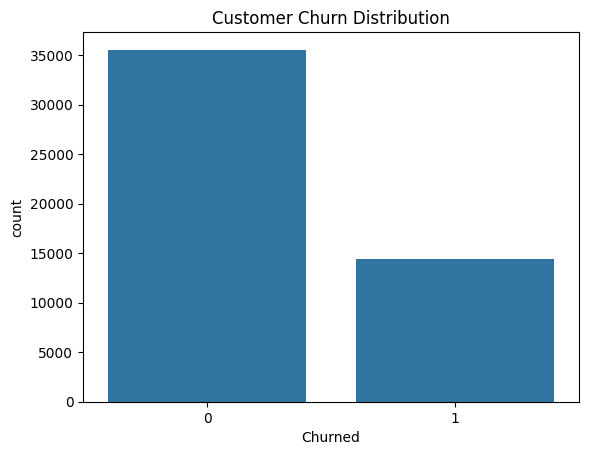

In [12]:
sns.countplot(x='Churned', data=df)
plt.title("Customer Churn Distribution")
plt.show()

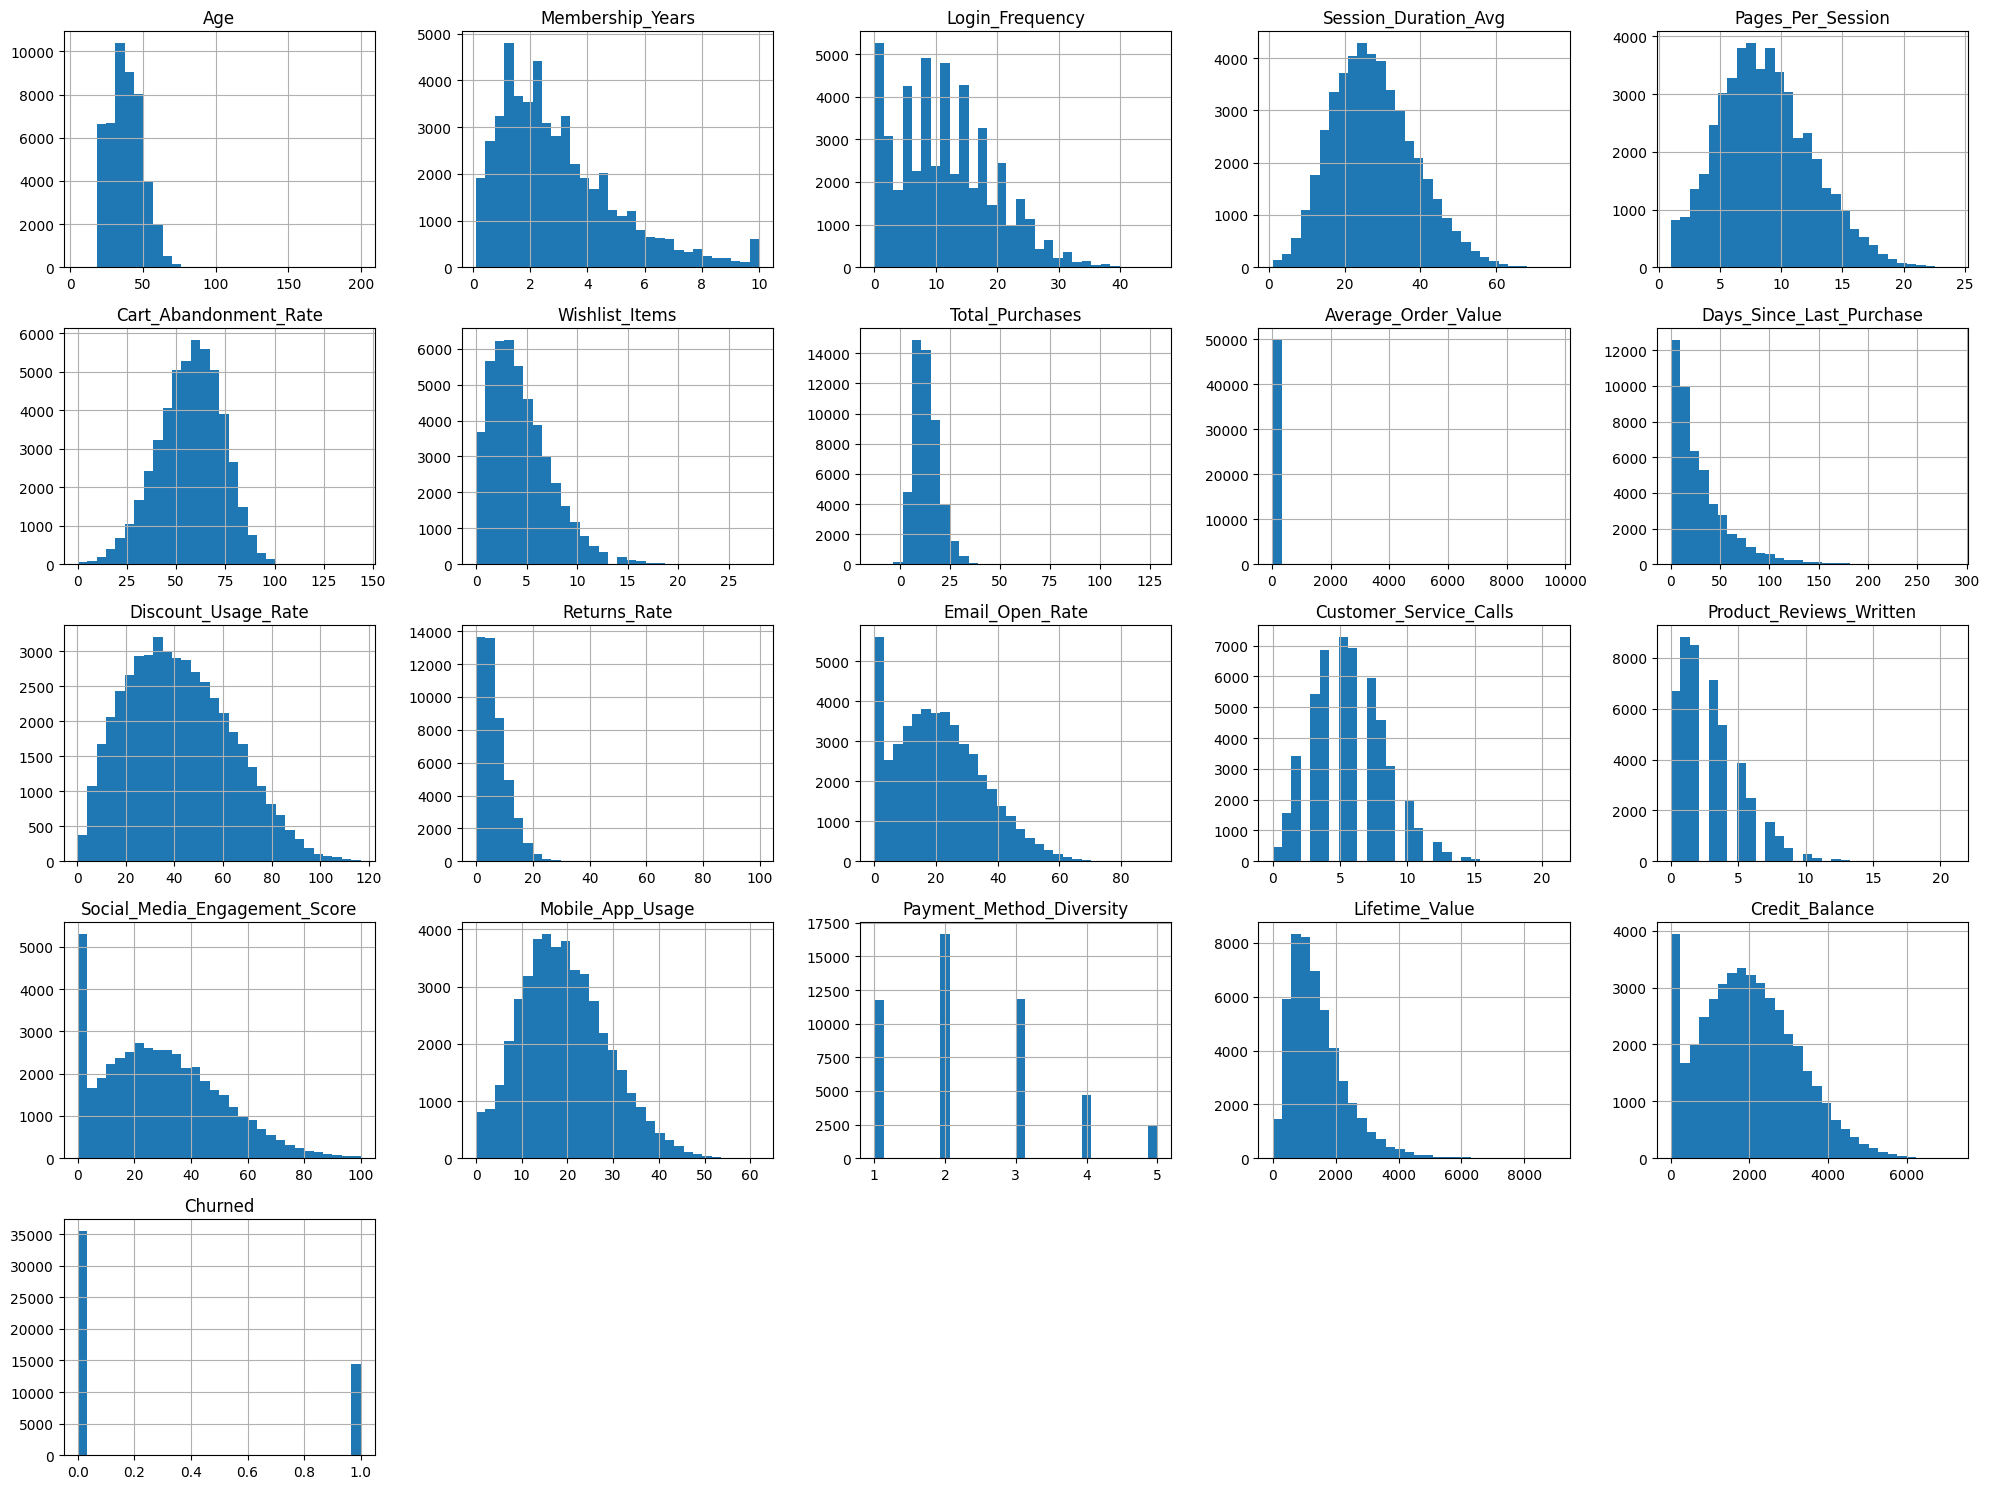

In [13]:
numerical_cols = df.select_dtypes(include=np.number).columns

df[numerical_cols].hist(
    figsize=(20,15),
    bins=30
)

plt.tight_layout()
plt.show()

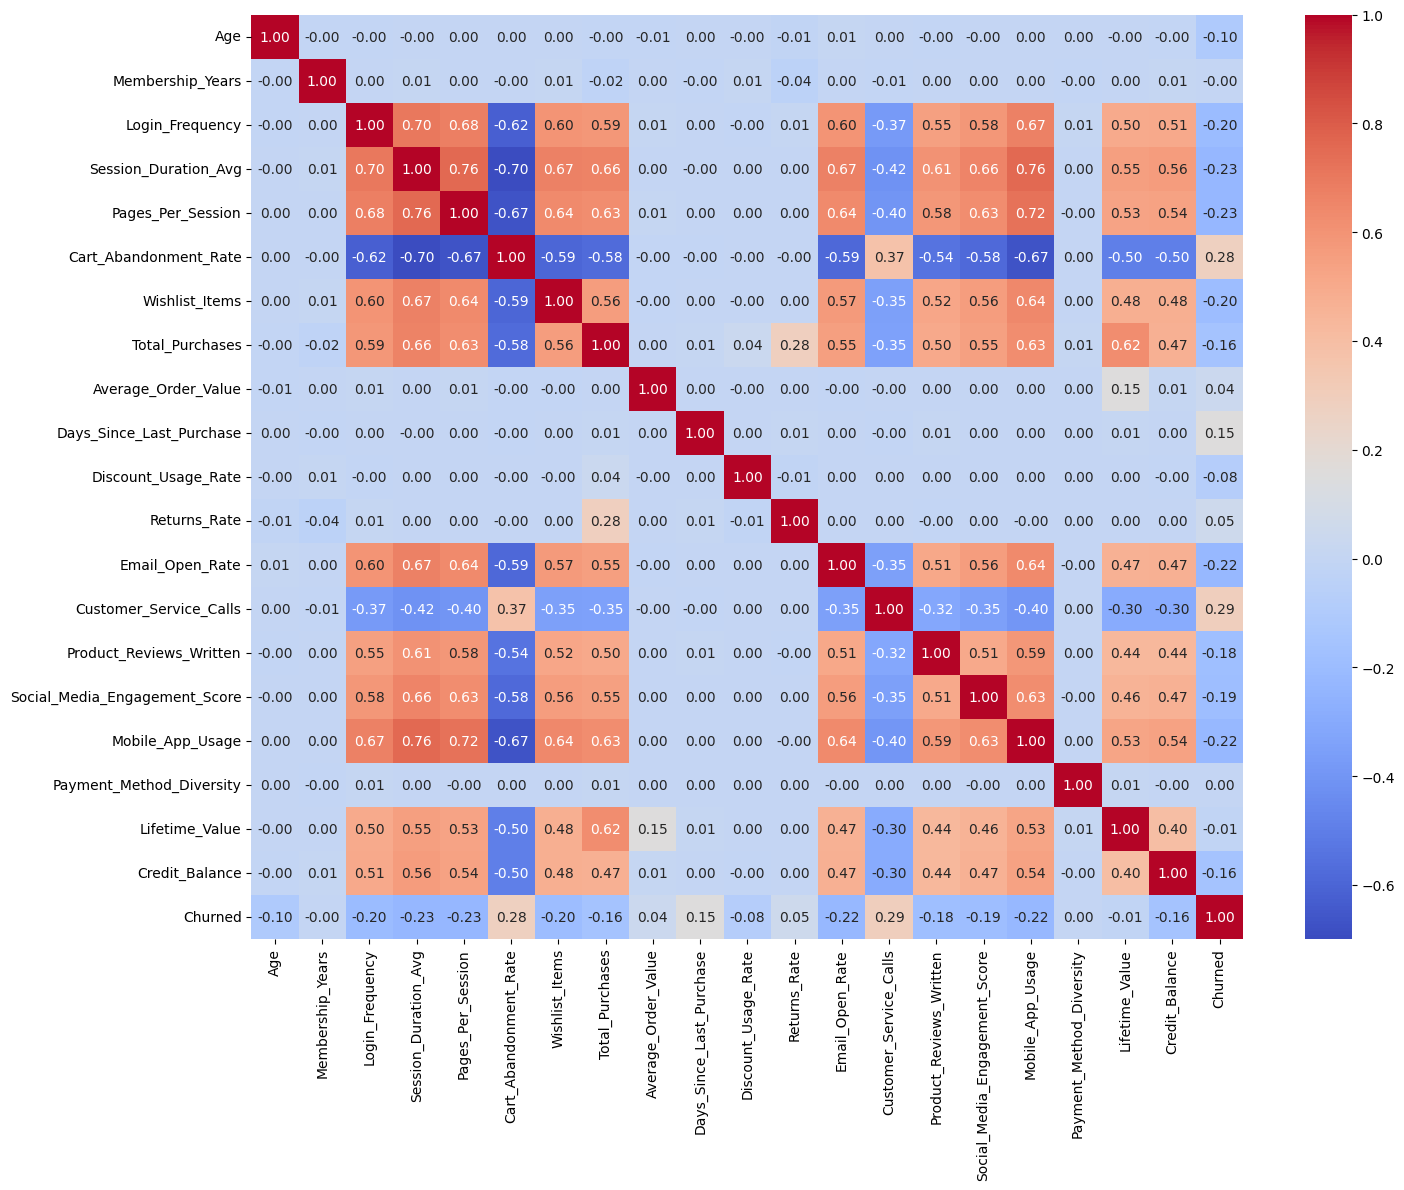

In [14]:
plt.figure(figsize=(16,12))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.show()

In [15]:
categorical_cols = df.select_dtypes(include='object').columns

categorical_cols

Index(['Gender', 'Country', 'City', 'Signup_Quarter'], dtype='object')

In [16]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

In [17]:
encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,1,2,21,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0.0,0
1,36.0,1,6,20,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,27.6,23.3,3.0,1067.47,3028.0,0.0,3
2,45.0,0,1,38,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,27.6,8.8,2.0,1289.75,2317.0,0.0,3
3,56.0,0,7,27,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0.0,0
4,35.0,1,4,9,3.1,29.0,51.4,8.4,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0.0,3


In [18]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    df.drop('Churned', axis=1)
)

scaled_df = pd.DataFrame(
    scaled_features,
    columns=df.drop('Churned', axis=1).columns
)

scaled_df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Signup_Quarter
0,0.449670,0.902336,-0.969735,0.181795,-0.040799,0.304118,-0.019266,-0.741695,-0.397970,-0.416436,...,-0.777562,-0.214209,1.242772,0.534652,-0.665654,0.168429,-1.231912,-0.537119,0.276395,-1.344075
1,-0.157149,0.902336,0.613454,0.089855,-0.672148,0.432150,1.438275,0.431898,-1.190229,-1.069915,...,0.448591,1.578436,0.494218,0.091480,-0.080417,0.448109,0.612019,-0.411309,0.925225,1.342606
2,0.623047,-0.963614,-1.365533,1.744776,-0.040799,-0.208008,-0.266953,-1.942582,0.848763,-1.069915,...,0.840279,-1.502898,-0.628613,-0.794865,-0.080417,-1.174035,-0.309946,-0.166302,0.310134,1.342606
3,1.576619,-0.963614,1.009252,0.733435,-0.186495,-0.208008,1.028639,1.660078,-0.944567,1.544001,...,-0.198545,1.477645,-1.377168,0.977824,2.938988,1.309524,0.612019,0.992343,0.618977,-1.344075
4,-0.243837,0.902336,-0.178141,-0.921486,0.056331,2.224591,2.267073,-0.086666,-2.332555,1.544001,...,-0.181515,1.225666,-1.751445,3.636856,2.788795,3.479841,1.533984,1.764322,2.937463,1.342606


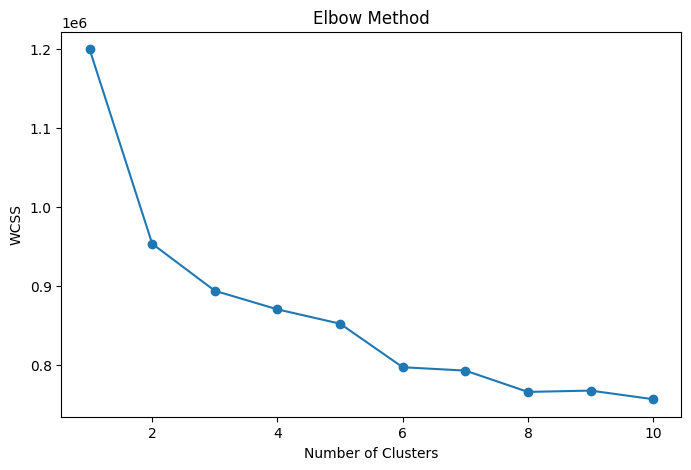

In [19]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

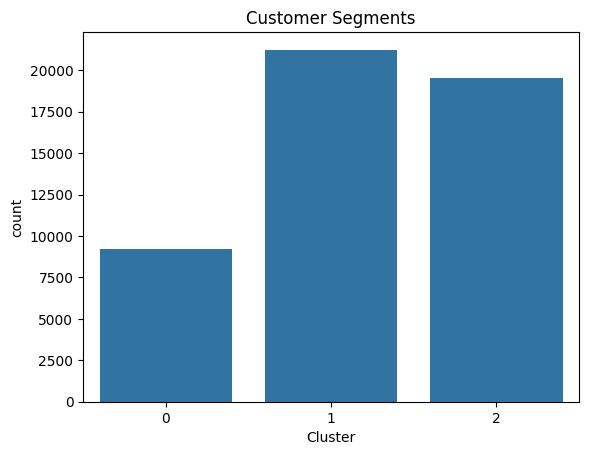

In [22]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)


df['Cluster'] = kmeans.fit_predict(scaled_df)

sns.countplot(x='Cluster', data=df)

plt.title("Customer Segments")
plt.show()

In [25]:
score = silhouette_score(
    scaled_df,
    df['Cluster']
)

print("Silhouette Score :", score)

Silhouette Score : 0.10468592704407075


In [26]:
X = df.drop(
    ['Churned','Cluster'],
    axis=1
)

y = df['Churned']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [30]:
y_pred = rf.predict(X_test)

In [31]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)

Accuracy : 0.9176


In [32]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.92      0.97      0.94      7110
         1.0       0.92      0.78      0.85      2890

    accuracy                           0.92     10000
   macro avg       0.92      0.88      0.89     10000
weighted avg       0.92      0.92      0.92     10000



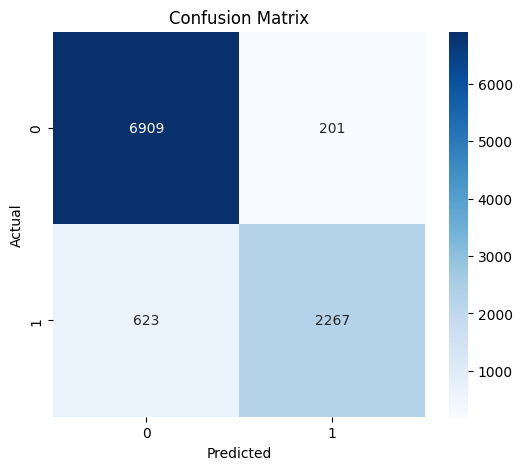

In [33]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [34]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
21,Lifetime_Value,0.128194
16,Customer_Service_Calls,0.121345
8,Cart_Abandonment_Rate,0.098364
13,Discount_Usage_Rate,0.066587
0,Age,0.066560
12,Days_Since_Last_Purchase,0.056099
10,Total_Purchases,0.050399
15,Email_Open_Rate,0.045897
11,Average_Order_Value,0.045270
6,Session_Duration_Avg,0.038996


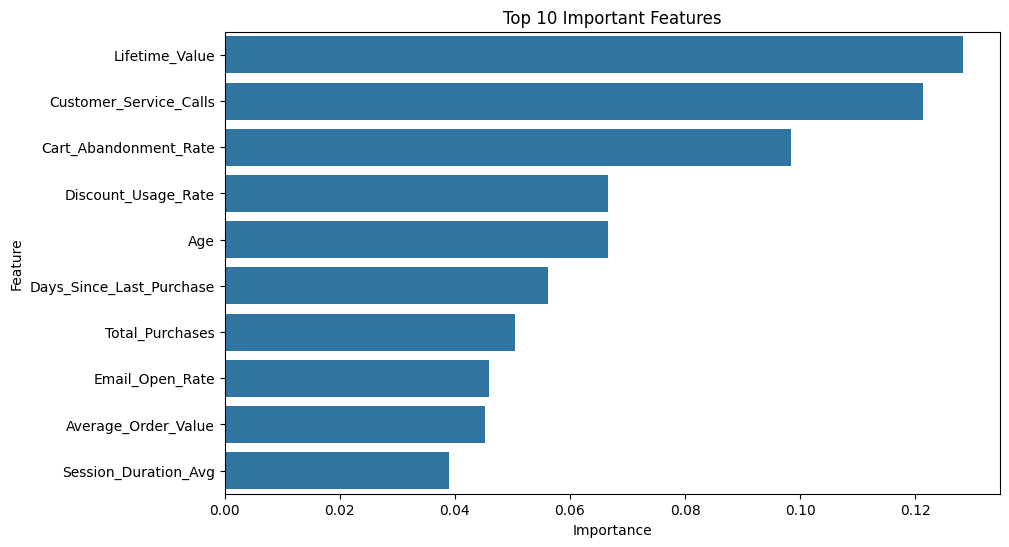

In [35]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()